# Air Quality Index (AQI) Analysis — Indian Cities (2015-2024)

## Overview
This project analyzes air quality trends across major Indian cities using 
18,000+ records from 2015 to 2024. It covers pollutant breakdown, seasonal 
patterns, COVID lockdown impact, and Diwali pollution spikes.

## Tools Used
- Python, Pandas, Matplotlib, Seaborn, Plotly

## Dataset
- Source: Kaggle — Air Quality Data in India (2015-2024)
- Records: 18,265 rows across 5 cities

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the dataset
df = pd.read_csv("city_day.csv")

# Drop Xylene column - too many missing values
df = df.drop(columns=['Xylene'])

# Fill missing numbers with average
df['PM2.5'] = df['PM2.5'].fillna(df['PM2.5'].mean())
df['PM10'] = df['PM10'].fillna(df['PM10'].mean())
df['NO2'] = df['NO2'].fillna(df['NO2'].mean())
df['CO'] = df['CO'].fillna(df['CO'].mean())
df['AQI'] = df['AQI'].fillna(df['AQI'].mean())

# Drop rows where AQI_Bucket is missing
df = df.dropna(subset=['AQI_Bucket'])

# Convert Datetime column (new dataset uses 'Datetime' not 'Date')
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Extract Month and Year
df['Month'] = df['Datetime'].dt.month
df['Year'] = df['Datetime'].dt.year

# Confirm everything worked
print("Shape:", df.shape)
print("Year range:", df['Year'].min(), "to", df['Year'].max())
print("Total cities:", df['City'].nunique())

Shape: (18265, 17)
Year range: 2015 to 2024
Total cities: 5


C:\Users\Hp\AppData\Local\Temp\ipykernel_8612\1892861712.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_aqi.values, y=city_aqi.index, palette='Reds_r')


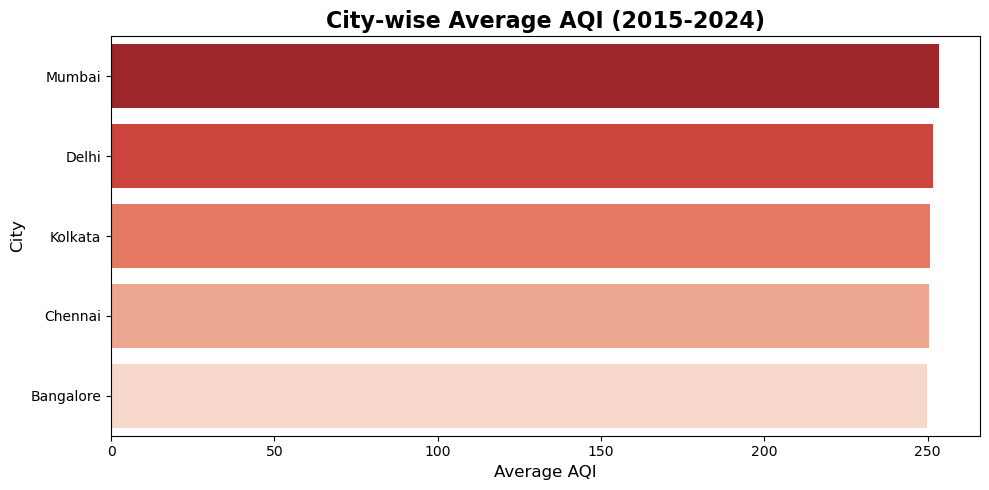

In [7]:
# City-wise average AQI
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=city_aqi.values, y=city_aqi.index, palette='Reds_r')

plt.title('City-wise Average AQI (2015-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Average AQI', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.tight_layout()
plt.show()

## 1. City-wise AQI Analysis
Mumbai has the highest average AQI among all cities from 2015-2024.

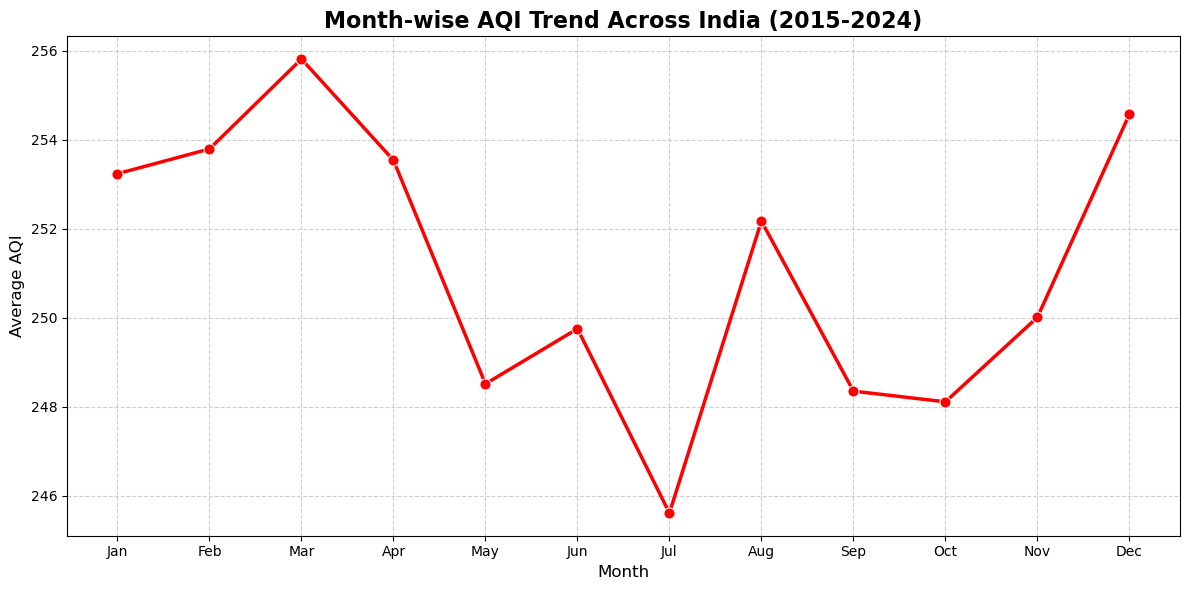

In [8]:
# Month-wise average AQI
month_aqi = df.groupby('Month')['AQI'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
sns.lineplot(x=month_names, y=month_aqi.values, marker='o',
             color='red', linewidth=2.5, markersize=8)

plt.title('Month-wise AQI Trend Across India (2015-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 2. Month-wise AQI Trend
December has the highest pollution due to winter fog. July is cleanest due to monsoon rains.

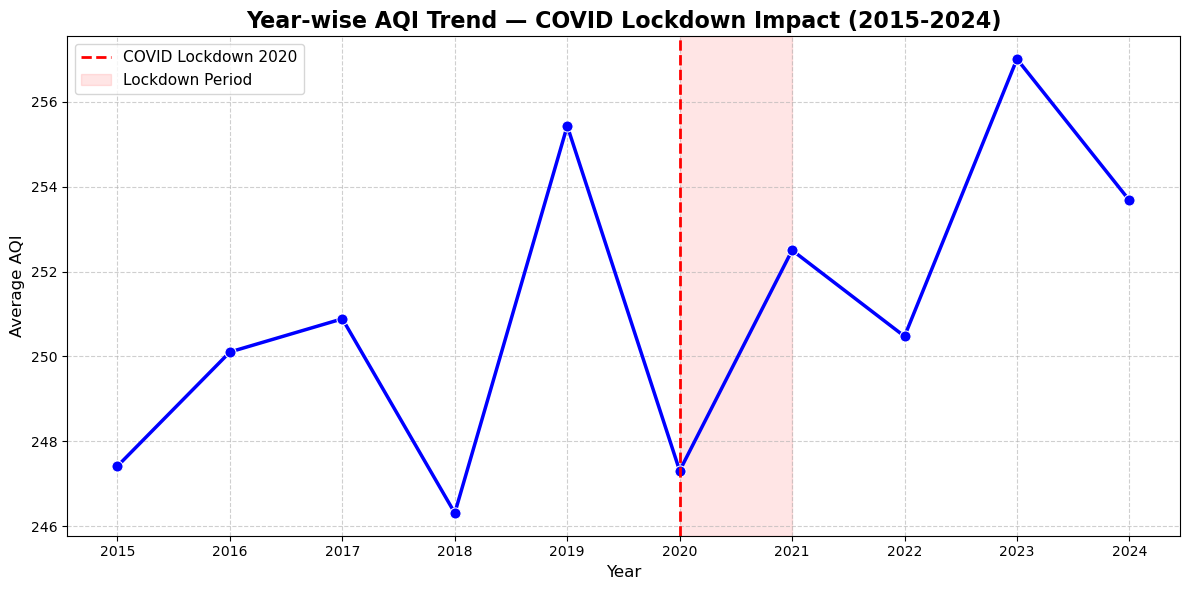

In [9]:
# Year-wise average AQI
year_aqi = df.groupby('Year')['AQI'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=year_aqi.index, y=year_aqi.values, marker='o',
             color='blue', linewidth=2.5, markersize=8)

# Add COVID lockdown marker
plt.axvline(x=2020, color='red', linestyle='--', linewidth=2, label='COVID Lockdown 2020')
plt.axvspan(2020, 2021, alpha=0.1, color='red', label='Lockdown Period')

plt.title('Year-wise AQI Trend — COVID Lockdown Impact (2015-2024)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(year_aqi.index)
plt.tight_layout()
plt.show()

## 3. COVID Lockdown Impact
AQI in 2020 did not drop significantly — 2018 had even lower AQI levels.

C:\Users\Hp\AppData\Local\Temp\ipykernel_8612\4046807757.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=diwali_aqi.index, y=diwali_aqi.values, palette='Oranges_r')


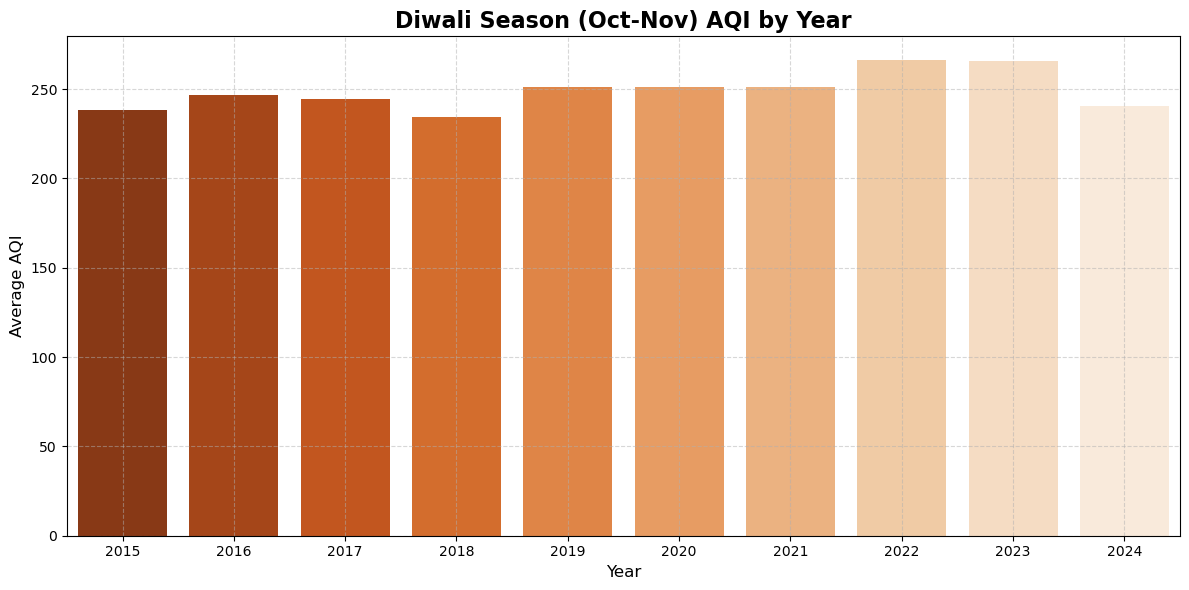

In [10]:
# Filter October and November data
diwali_df = df[df['Month'].isin([10, 11])]

# Year-wise average AQI during Diwali months
diwali_aqi = diwali_df.groupby('Year')['AQI'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=diwali_aqi.index, y=diwali_aqi.values, palette='Oranges_r')

plt.title('Diwali Season (Oct-Nov) AQI by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Diwali Pollution Spike
2022 recorded the worst Diwali season pollution across all years.

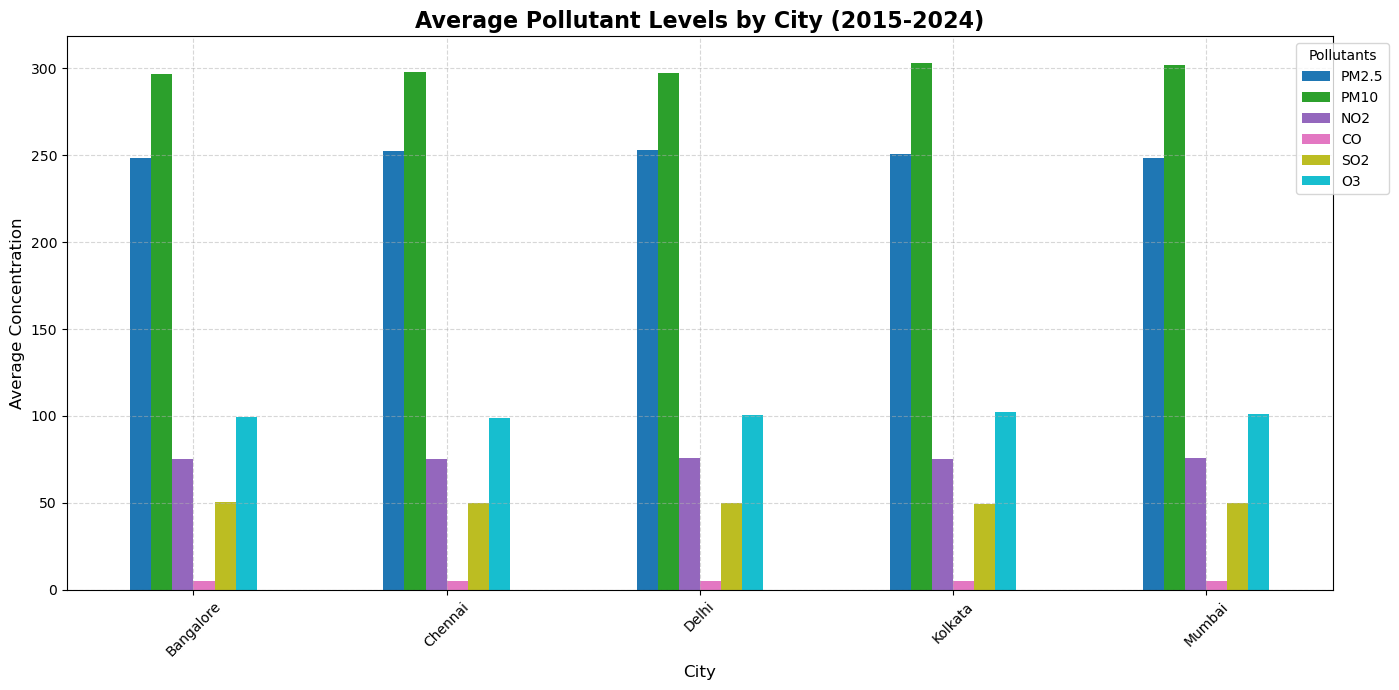

In [11]:
# Average pollutants per city
pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
city_pollutants = df.groupby('City')[pollutants].mean()

# Plot
city_pollutants.plot(kind='bar', figsize=(14, 7), colormap='tab10')

plt.title('Average Pollutant Levels by City (2015-2024)', 
          fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Concentration', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Pollutants', bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Pollutant Breakdown
PM10 is the dominant pollutant across all Indian cities.

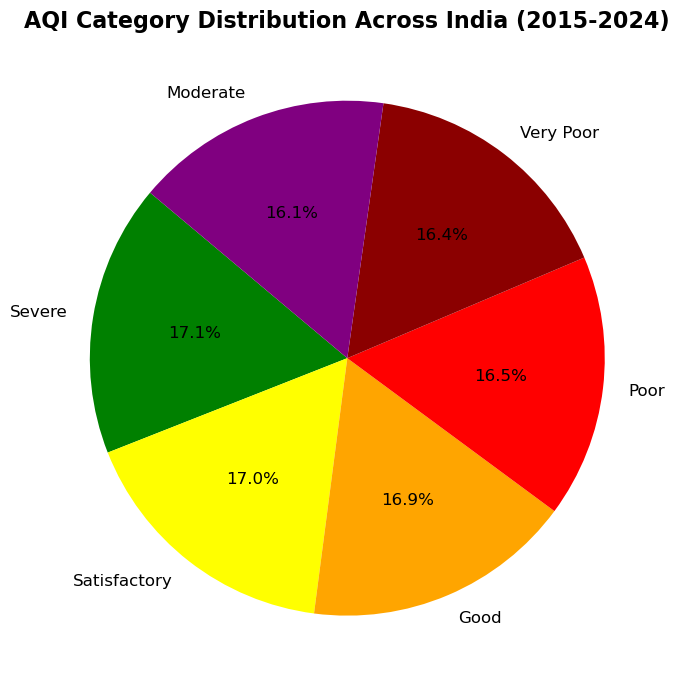

In [12]:
# Count each AQI category
aqi_counts = df['AQI_Bucket'].value_counts()

# Define colors for each category
colors = ['green', 'yellow', 'orange', 'red', 'darkred', 'purple']

plt.figure(figsize=(10, 7))
plt.pie(aqi_counts.values, 
        labels=aqi_counts.index, 
        colors=colors[:len(aqi_counts)],
        autopct='%1.1f%%',
        startangle=140,
        textprops={'fontsize': 12})

plt.title('AQI Category Distribution Across India (2015-2024)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. AQI Category Distribution
Only 16.9% of days had Good air quality over 9 years across Indian cities.

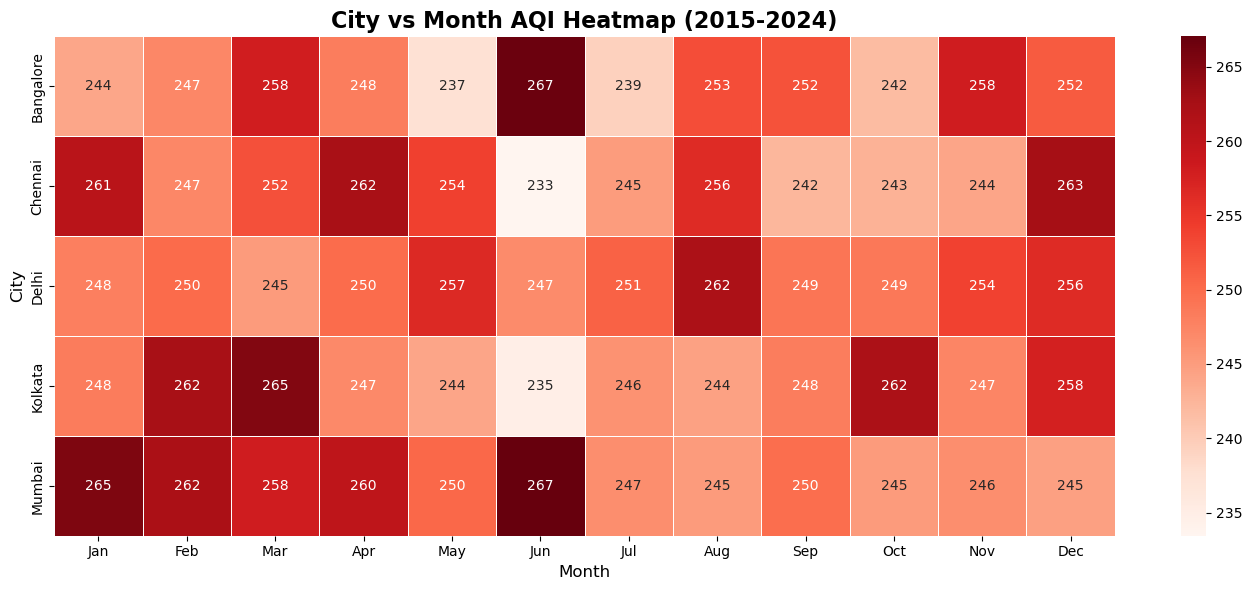

In [13]:
# City vs Month AQI heatmap
heatmap_data = df.groupby(['City', 'Month'])['AQI'].mean().unstack()

# Rename month numbers to names
heatmap_data.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.0f',
            cmap='Reds',
            linewidths=0.5,
            annot_kws={'size': 10})

plt.title('City vs Month AQI Heatmap (2015-2024)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.tight_layout()
plt.show()

## 7. City vs Month Heatmap
Bangalore in June recorded the highest city-month AQI combination — a surprising finding.

## Key Findings

1. **Mumbai** has the highest average AQI across 2015-2024
2. **December** is the most polluted month; **July** is the cleanest due to monsoon
3. **COVID lockdown (2020)** did not reduce AQI below 2018 levels — suggesting structural pollution issues
4. **2022 Diwali season** recorded the worst festive pollution in 9 years
5. **PM10** is the dominant pollutant across all Indian cities
6. Only **16.9% of days** had Good air quality over 9 years
7. **Bangalore in June** surprisingly recorded the highest city-month AQI combination